# Exploratory Data Analysis (EDA)
This notebook explores the structure, quality, distribution, and characteristics of the CEFR vocabulary dataset.

# Import Libraries

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')

In [4]:
def save_plot(base_dir, filename):
    output_dir = base_dir / "data" / "processed"
    output_dir.mkdir(parents=True, exist_ok=True)

    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)

# Load Dataset

In [5]:
base_dir = Path.cwd().parent
file_path = base_dir / 'data' / 'clean_dataset.xlsx'
df = pd.read_excel(file_path)
print(df.shape)
df.head()

(14848, 5)


,#,phrase,level,main category,sub category
0,1,after-sales service,C2,Business_Finance_Economy,Business_Management
1,2,ancient monument,C2,Education,Academic_Study
2,3,arrive at a total of,C2,Business_Finance_Economy,Economy_Markets
3,4,birth rate,B2,Business_Finance_Economy,Economy_Markets
4,5,become famous,C2,Psychology_Emotions,Motivation


# Dataset Overview
This section reviews the dataset structure, data types, summary statistics, and missing values.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14848 entries, 0 to 14847
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   #              14848 non-null  int64
 1   phrase         14848 non-null  str  
 2   level          14848 non-null  str  
 3   main category  14848 non-null  str  
 4   sub category   14848 non-null  str  
dtypes: int64(1), str(4)
memory usage: 580.1 KB


In [7]:
df.describe(include='all')

,#,phrase,level,main category,sub category
count,14848.000000,14848,14848,14848,14848
unique,NaN,14247,6,10,51
top,NaN,abandon,B1,Daily_Life,General_Interactions
freq,NaN,2,10315,10773,10460
mean,7424.500000,NaN,NaN,NaN,NaN
std,4286.392734,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,3712.750000,NaN,NaN,NaN,NaN
50%,7424.500000,NaN,NaN,NaN,NaN
75%,11136.250000,NaN,NaN,NaN,NaN


In [8]:
df.isnull().sum()

#                0
phrase           0
level            0
main category    0
sub category     0
dtype: int64

# CEFR Level Distribution
This section analyzes the distribution of CEFR proficiency levels and identifies class imbalance.

In [9]:
level_counts = df['level'].value_counts()
level_counts

level
B1    10315
C2     2324
B2      876
C1      846
A2      394
A1       93
Name: count, dtype: int64

C:\Users\panteaa\AppData\Local\Temp\ipykernel_18412\1284660724.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


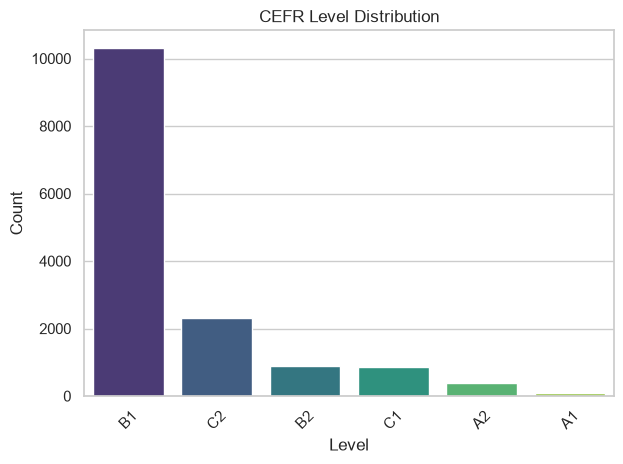

In [10]:
sns.barplot(
    x=level_counts.index,
    y=level_counts.values,
    palette="viridis"
)

plt.title("CEFR Level Distribution")
plt.xlabel("Level")
plt.ylabel("Count")
plt.xticks(rotation=45)

save_plot(base_dir, "cefr_level_distribution.png")


plt.show()

# Main Category Analysis
This section explores the distribution of vocabulary across the main semantic categories.

In [11]:
main_counts = df['main category'].value_counts()
main_counts

main category
Daily_Life                  10773
Communication_Media_Arts      664
Technology_Digital            589
Business_Finance_Economy      570
Health_Medicine               526
Psychology_Emotions           489
Education                     411
Science_Nature                305
Society_Law_Politics          275
Travel_Transportation         246
Name: count, dtype: int64

C:\Users\panteaa\AppData\Local\Temp\ipykernel_18412\353255074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


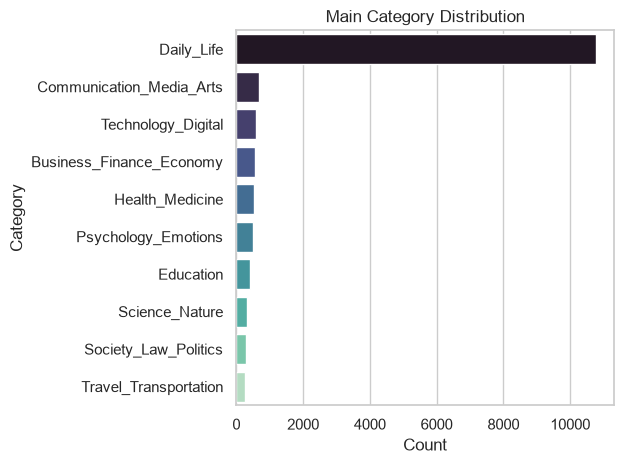

In [12]:
main_counts = df["main category"].value_counts()

sns.barplot(
    y=main_counts.index,
    x=main_counts.values,
    palette="mako"
)

plt.title("Main Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")


save_plot(base_dir, "main_categories.png")
plt.show()

# Sub Category Analysis
This section identifies the most frequent subcategories in the dataset.

In [13]:
sub_counts = df['sub category'].value_counts()
sub_counts.head(20)

sub category
General_Interactions       10460
Artificial_Intelligence      372
Speaking_Expressions         301
Healthcare_Hospital          257
Economy_Markets              251
Law_Crime                    189
Behavior                     189
Feelings_Emotions            174
Arts_Creativity              173
Road_Travel                  147
Software_Internet            142
Natural_Phenomena            125
Jobs_Careers                 118
Illness_Diseases             112
Home_Housing                 109
Exams_Assessments            105
Finance_Banking               92
Business_Management           86
Learning_Skills               79
Academic_Study                78
Name: count, dtype: int64

C:\Users\panteaa\AppData\Local\Temp\ipykernel_18412\3385473839.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


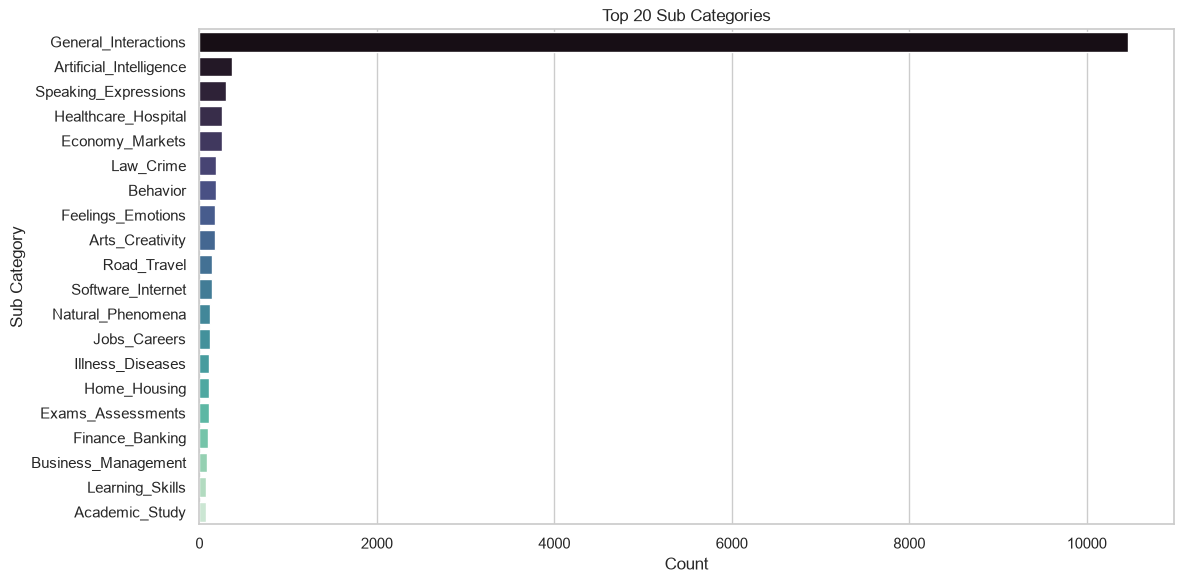

In [14]:
sns.set_theme(style="whitegrid")
top20 = sub_counts.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top20.values,
    y=top20.index,
    palette="mako"
)

plt.title("Top 20 Sub Categories")
plt.xlabel("Count")
plt.ylabel("Sub Category")
plt.tight_layout()
save_plot(base_dir, "top_20_sub_categories.png")
plt.show()

# Phrase Length Analysis
This section investigates the length of vocabulary items measured by the number of words per phrase.

In [15]:
df['phrase_length'] = df['phrase'].apply(lambda x: len(str(x).split()))

In [16]:
df['phrase_length'].describe()

count    14848.000000
mean         1.623922
std          0.952427
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: phrase_length, dtype: float64

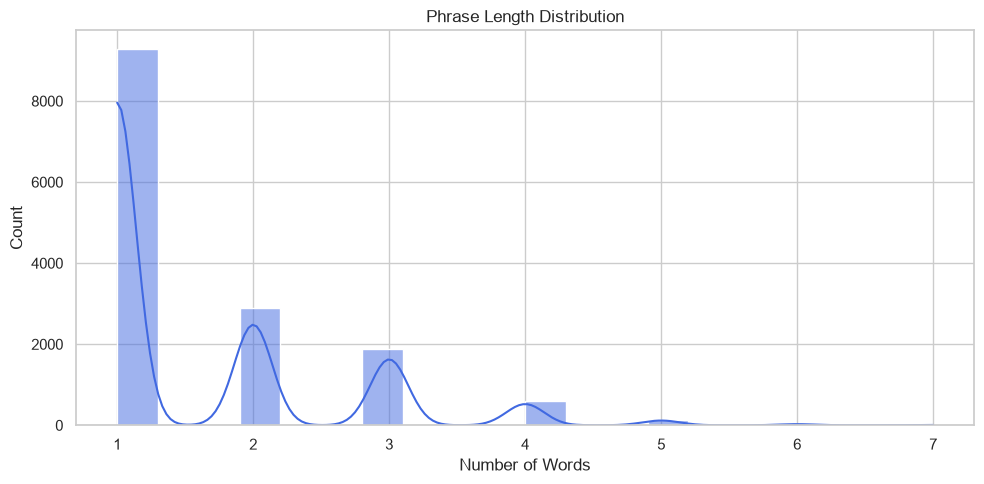

In [17]:
output_dir = base_dir / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))

sns.histplot(
    df["phrase_length"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Phrase Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(output_dir / "phrase_length_distribution.png", dpi=300)
plt.show()

# Relationship Analysis
This section explores relationships between CEFR levels, categories, and phrase lengths.

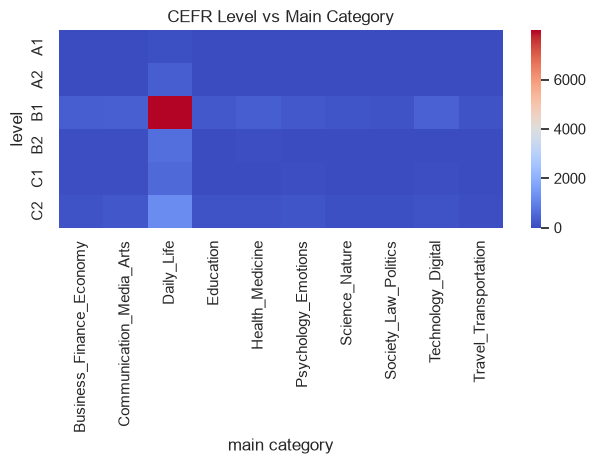

In [18]:
pivot = pd.crosstab(df["level"], df["main category"])
sns.heatmap(pivot, cmap="coolwarm", annot=False)
plt.title("CEFR Level vs Main Category")

save_plot(base_dir, "CEFR Level vs Main Category.png")
plt.show()

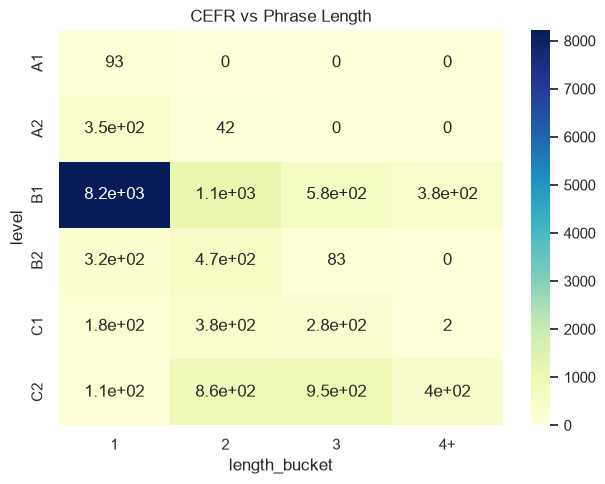

In [19]:
df["length_bucket"] = pd.cut(
    df["phrase_length"],
    bins=[0,1,2,3,10],
    labels=["1","2","3","4+"]
)

pivot2 = pd.crosstab(df["level"], df["length_bucket"])
sns.heatmap(pivot2, cmap="YlGnBu", annot=True)


save_plot(base_dir, "CEFR Level vs Phrase Length.png")
plt.title("CEFR vs Phrase Length")
plt.show()

# Key Findings
## Dataset Characteristics
- 14,848 vocabulary entries
- No missing values
- No duplicate records

## CEFR Distribution
- Strong class imbalance
- B1 is the dominant level

## Category Distribution
- Daily_Life contains most entries
- Travel_Transportation contains the fewest entries

## Phrase Structure
- Most entries are single-word vocabulary items
- Average phrase length is approximately 1.62 words

## Implications
- Suitable for embeddings and semantic analysis
- Suitable for clustering and similarity search
- Less suitable for balanced classification without additional preprocessing